# Maven Fuzzy Factory — Traffic & Funnel Analysis

**Business question:** which marketing channels earn their budget, and where does the site lose visitors before they buy?

This notebook pulls together `sql/01` through `sql/08` into the charts and headline numbers for the case study. Each section mirrors one stage of the analysis: channel volume, channel conversion (and why it's misleading without controlling for repeat visitors), device bidding, and the checkout funnel.

In [1]:
## Setup

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from portfolio import PALETTE, apply_house_style, get_engine, run_sql_file
from portfolio.paths import project_dir

apply_house_style()                        # shared chart look across the whole portfolio
pd.set_option("display.max_columns", None)

PROJECT = project_dir("05-marketing-funnel")
SQL = PROJECT / "sql"
FIG = PROJECT / "outputs" / "figures"

engine = get_engine()                       # reads MFF_DB_URL from .env, session tz pinned to +00:00

## 1. Traffic landscape and channel conversion

`gsearch/nonbrand` is ~60% of all sessions. Query 02 (all sessions) makes brand search and direct/organic look like better converters — query 03 (new visitors only) shows that's mostly a repeat-visitor mix effect, not a real intent premium.

In [3]:
channel_conv = run_sql_file(SQL / "02_conversion_by_channel.sql", engine)
channel_conv["channel"] = channel_conv["utm_source"] + " / " + channel_conv["utm_campaign"]
channel_conv

,utm_source,utm_campaign,sessions,orders,conversion_rate_pct,channel
0,gsearch,nonbrand,282706,18822,6.66,gsearch / nonbrand
1,(none),(none),83328,6118,7.34,(none) / (none)
2,bsearch,nonbrand,54909,3818,6.95,bsearch / nonbrand
3,gsearch,brand,33329,2511,7.53,gsearch / brand
4,bsearch,brand,7914,701,8.86,bsearch / brand
5,socialbook,desktop_targeted,5590,288,5.15,socialbook / desktop_targeted
6,socialbook,pilot,5095,55,1.08,socialbook / pilot


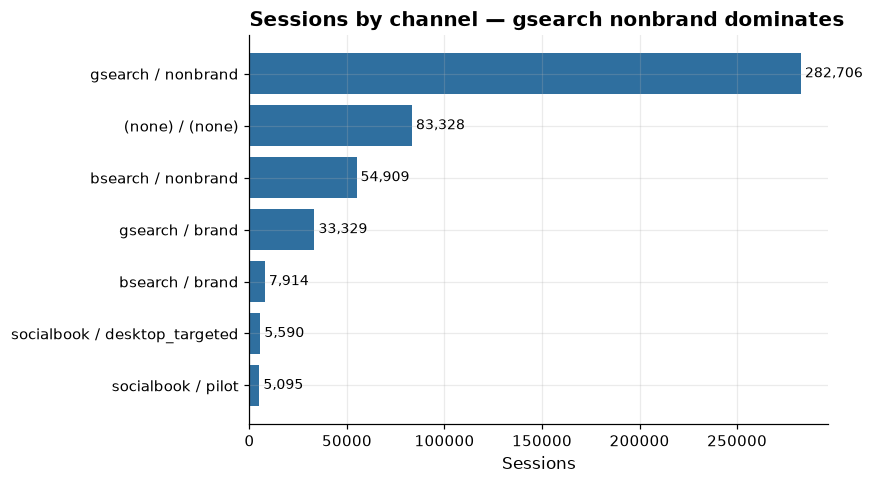

In [4]:
plot_df = channel_conv.sort_values("sessions", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_df["channel"], plot_df["sessions"], color=PALETTE[0])
ax.set_xlabel("Sessions")
ax.set_title("Sessions by channel — gsearch nonbrand dominates")
for y, sessions in enumerate(plot_df["sessions"]):
    ax.text(sessions, y, f" {sessions:,}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "01_sessions_by_channel.png")
plt.show()

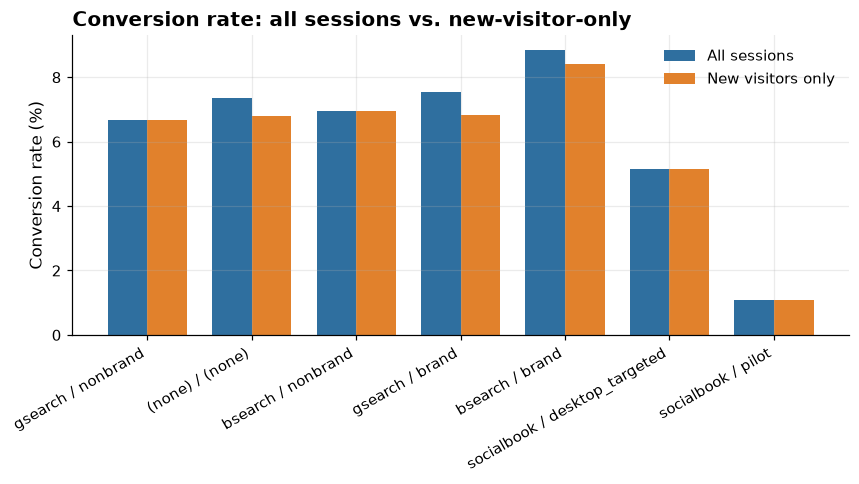

In [5]:
new_conv = run_sql_file(SQL / "03_conversion_new_visitors.sql", engine)
new_conv["channel"] = new_conv["utm_source"] + " / " + new_conv["utm_campaign"]

compare = channel_conv.merge(
    new_conv[["channel", "conversion_rate_pct"]],
    on="channel",
    suffixes=("_all", "_new_only"),
).sort_values("sessions", ascending=False)

x = range(len(compare))
width = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar([i - width / 2 for i in x], compare["conversion_rate_pct_all"], width, label="All sessions", color=PALETTE[0])
ax.bar([i + width / 2 for i in x], compare["conversion_rate_pct_new_only"], width, label="New visitors only", color=PALETTE[1])
ax.set_xticks(list(x))
ax.set_xticklabels(compare["channel"], rotation=30, ha="right")
ax.set_ylabel("Conversion rate (%)")
ax.set_title("Conversion rate: all sessions vs. new-visitor-only")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "02_conversion_all_vs_new.png")
plt.show()

**Takeaway:** brand and direct/organic conversion drops to roughly the same level as nonbrand once repeat visitors are excluded (~6.7–6.9%). `socialbook/pilot` is a clear outlier at 1.08% — 5x worse than its sibling campaign.

## 2. Device bidding — gsearch nonbrand

Desktop converts ~2.6x better than mobile on the largest channel (8.22% vs 3.18%, new visitors). Both devices improved steadily over three years as the site got better, but the *ratio* between them has not closed.

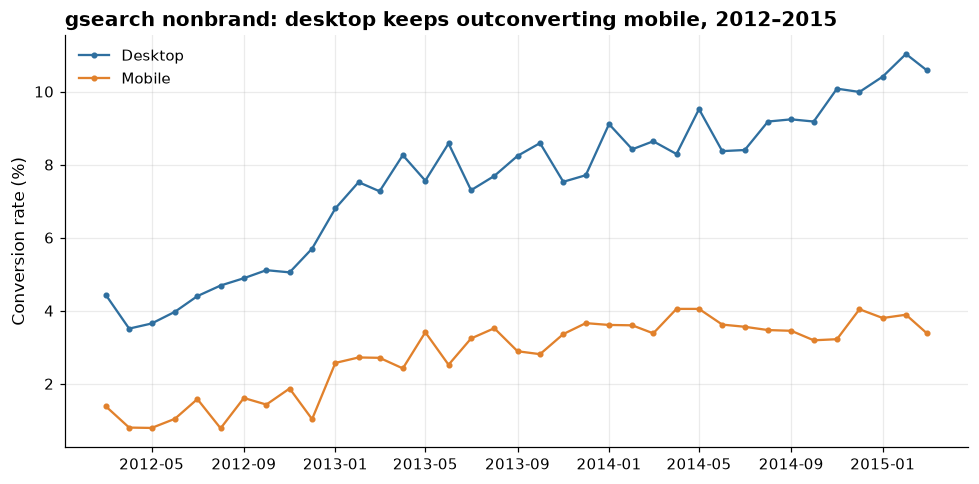

In [6]:
device_trend = run_sql_file(SQL / "05_gsearch_nonbrand_device_trend.sql", engine)
device_trend["month"] = pd.to_datetime(device_trend["month"], format="%Y-%m")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(device_trend["month"], device_trend["desktop_cvr_pct"], marker="o", markersize=3, label="Desktop", color=PALETTE[0])
ax.plot(device_trend["month"], device_trend["mobile_cvr_pct"], marker="o", markersize=3, label="Mobile", color=PALETTE[1])
ax.set_ylabel("Conversion rate (%)")
ax.set_title("gsearch nonbrand: desktop keeps outconverting mobile, 2012–2015")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "03_device_conversion_trend.png")
plt.show()

**Takeaway:** the desktop/mobile gap narrowed through 2013–14 then widened again in early 2015 — not a closing gap. Recommend a mobile bid discount of roughly 50–60%, re-checked quarterly.

## 3. The checkout funnel

Where do visitors drop off between landing and placing an order?

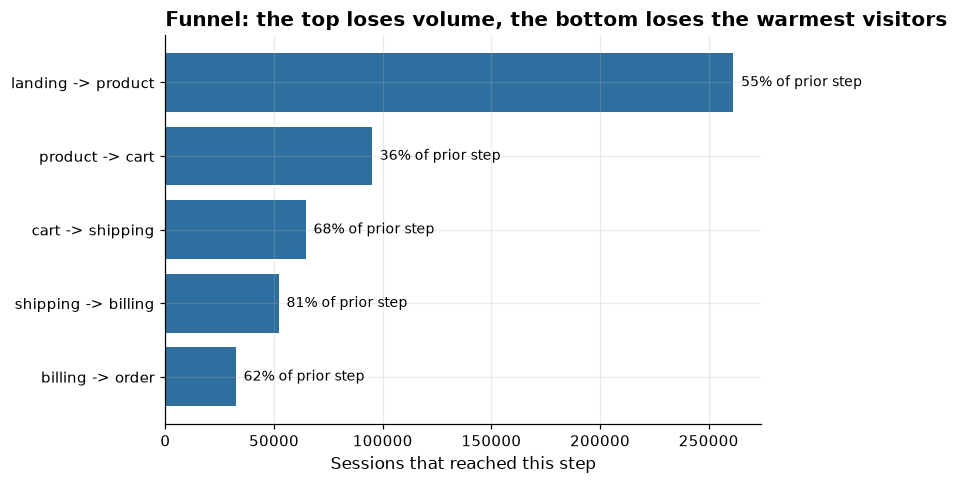

In [7]:
funnel = run_sql_file(SQL / "08_funnel_conversion_rates.sql", engine)

step_order = ["landing -> product", "product -> cart", "cart -> shipping", "shipping -> billing", "billing -> order"]
funnel["funnel_step"] = pd.Categorical(funnel["funnel_step"], categories=step_order, ordered=True)
funnel = funnel.sort_values("funnel_step")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(funnel["funnel_step"].astype(str), funnel["sessions_through"], color=PALETTE[0])
ax.invert_yaxis()                            # landing at the top, order at the bottom
ax.set_xlabel("Sessions that reached this step")
ax.set_title("Funnel: the top loses volume, the bottom loses the warmest visitors")
for bar, pct in zip(bars, funnel["step_click_through_pct"]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f"  {pct:.0f}% of prior step", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "04_funnel.png")
plt.show()

**Takeaway:** landing→product and product→cart lose the most raw sessions (normal browsing behaviour, but the biggest lever by volume). `billing→order` at 62.1% is the most concerning single number — 38% of the most qualified visitors in the funnel (already in checkout) abandon at the payment step.

## Findings

- The business runs on paid search (`gsearch`+`bsearch` ~72% of sessions); `gsearch/nonbrand` alone is 60%.
- Blended conversion rates flatter brand search and direct/organic — restricted to new visitors, nearly every channel converges to ~6.7–6.9%. `socialbook/pilot` is a genuine, isolated outlier (1.08%).
- Desktop converts ~2.6x better than mobile on the largest channel, and the gap has not closed over three years.
- The funnel loses the most volume at the top (landing/product browsing) but the most *qualified* traffic at the bottom (billing → order, 62.1%).
- The site already has 6 landing-page variants and two billing-page versions — evidence of prior A/B tests whose results are not yet quantified here.

## Recommendations

1. Apply a ~50–60% mobile bid discount on gsearch nonbrand; re-check the desktop/mobile ratio quarterly.
2. Investigate brand-search spend with a geo holdout test — ~64% of brand sessions are returning customers likely reachable for free.
3. Audit `socialbook/pilot`'s landing page and device mix before spending further on it.
4. Evaluate the billing-page redesign (`/billing` vs `/billing-2`) and the landing-page tests directly — next section of this project.

Full write-up: [`README.md`](../README.md)